We will construct a linear model that explains the relationship a car's mileage (mpg) has with its other attributes

## Import Libraries

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split # Sklearn package's randomized data splitting function
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Load and review data

In [2]:
cData = pd.read_csv("/content/auto-mpg.csv")
cData.shape

(398, 9)

In [3]:
# 8 variables:
#
# MPG (miles per gallon),
# cylinders,
# engine displacement (cu. inches),
# horsepower,
# vehicle weight (lbs.),
# time to accelerate from O to 60 mph (sec.),
# model year (modulo 100), and
# origin of car (1. American, 2. European,3. Japanese).
#
# Also provided are the car labels (types)
# Missing data values are marked by series of question marks.


cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
#dropping/ignoring car_name
cData = cData.drop('car name', axis=1)
# Also replacing the categorical var with actual values
cData['origin'] = cData['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,america
1,15.0,8,350.0,165,3693,11.5,70,america
2,18.0,8,318.0,150,3436,11.0,70,america
3,16.0,8,304.0,150,3433,12.0,70,america
4,17.0,8,302.0,140,3449,10.5,70,america


**Checking Cardinality of Categorical Column - Origin**

In [5]:
#cardinality for origin column
cData['origin'].value_counts()


,count
origin,
america,249
asia,79
europe,70


**Observation**


*   We have 3 unique values for origin we sufficient values so we can create 3 dummy variable for it



## Create Dummy Variables
Values like 'america' cannot be read into an equation. Using substitutes like 1 for america, 2 for europe and 3 for asia would end up implying that european cars fall exactly half way between american and asian cars! we dont want to impose such an baseless assumption!

So we create 3 simple true or false columns with titles equivalent to "Is this car America?", "Is this care European?" and "Is this car Asian?". These will be used as independent variables without imposing any kind of ordering between the three regions.




In [6]:
cData = pd.get_dummies(cData, columns=['origin'])
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,True,False,False
1,15.0,8,350.0,165,3693,11.5,70,True,False,False
2,18.0,8,318.0,150,3436,11.0,70,True,False,False
3,16.0,8,304.0,150,3433,12.0,70,True,False,False
4,17.0,8,302.0,140,3449,10.5,70,True,False,False


## Dealing with Missing Values

In [7]:
#A quick summary of the data columns
cData.describe()

,mpg,cylinders,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000


In [8]:
# hp is missing cause it does not seem to be reqcognized as a numerical column!
cData.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
model year,int64
origin_america,bool
origin_asia,bool
origin_europe,bool


In [9]:
# isdigit()? on 'horsepower'
hpIsDigit = pd.DataFrame(cData.horsepower.str.isdigit())  # if the string is made of digits store True else False

#print isDigit = False!
cData[hpIsDigit['horsepower'] == False]   # from temp take only those rows where hp has false


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,?,2046,19.0,71,True,False,False
126,21.0,6,200.0,?,2875,17.0,74,True,False,False
330,40.9,4,85.0,?,1835,17.3,80,False,False,True
336,23.6,4,140.0,?,2905,14.3,80,True,False,False
354,34.5,4,100.0,?,2320,15.8,81,False,False,True
374,23.0,4,151.0,?,3035,20.5,82,True,False,False


In [10]:
# Missing values have a'?''
# Replace missing values with NaN
cData = cData.replace('?', np.nan)
cData['horsepower'] = cData['horsepower'].astype(float)
cData[hpIsDigit['horsepower'] == False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,NaN,2046,19.0,71,True,False,False
126,21.0,6,200.0,NaN,2875,17.0,74,True,False,False
330,40.9,4,85.0,NaN,1835,17.3,80,False,False,True
336,23.6,4,140.0,NaN,2905,14.3,80,True,False,False
354,34.5,4,100.0,NaN,2320,15.8,81,False,False,True
374,23.0,4,151.0,NaN,3035,20.5,82,True,False,False


There are various ways to handle missing values. Drop the rows, replace missing values with median values etc. of the 398 rows 6 have NAN in the hp column. We could drop those 6 rows - which might not be a good idea under all situations


In [11]:
#instead of dropping the rows, lets replace the missing values with median value.
cData.median()

,0
mpg,23.0
cylinders,4.0
displacement,148.5
horsepower,93.5
weight,2803.5
acceleration,15.5
model year,76.0
origin_america,1.0
origin_asia,0.0
origin_europe,0.0


In [12]:
# replace the missing values with median value.
# Note, we do not need to specify the column names below
# every column's missing value is replaced with that column's median respectively  (axis =0 means columnwise)
#cData = cData.fillna(cData.median())

medianFiller = lambda x: x.fillna(x.median())
cData = cData.apply(medianFiller,axis=0)

cData['horsepower'] = cData['horsepower'].astype('float64')  # converting the hp column from object / string type to float


In [13]:
cData.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model year,int64
origin_america,bool
origin_asia,bool
origin_europe,bool


In [14]:
# Check missing values
print(cData.isnull().sum())

mpg               0
cylinders         0
displacement      0
horsepower        0
weight            0
acceleration      0
model year        0
origin_america    0
origin_asia       0
origin_europe     0
dtype: int64


**Observation**


*   We don't have anymore missing values



## BiVariate Plots

A bivariate analysis among the different variables can be done using scatter matrix plot. Seaborn libs create a dashboard reflecting useful information about the dimensions. The result can be stored as a .png file.

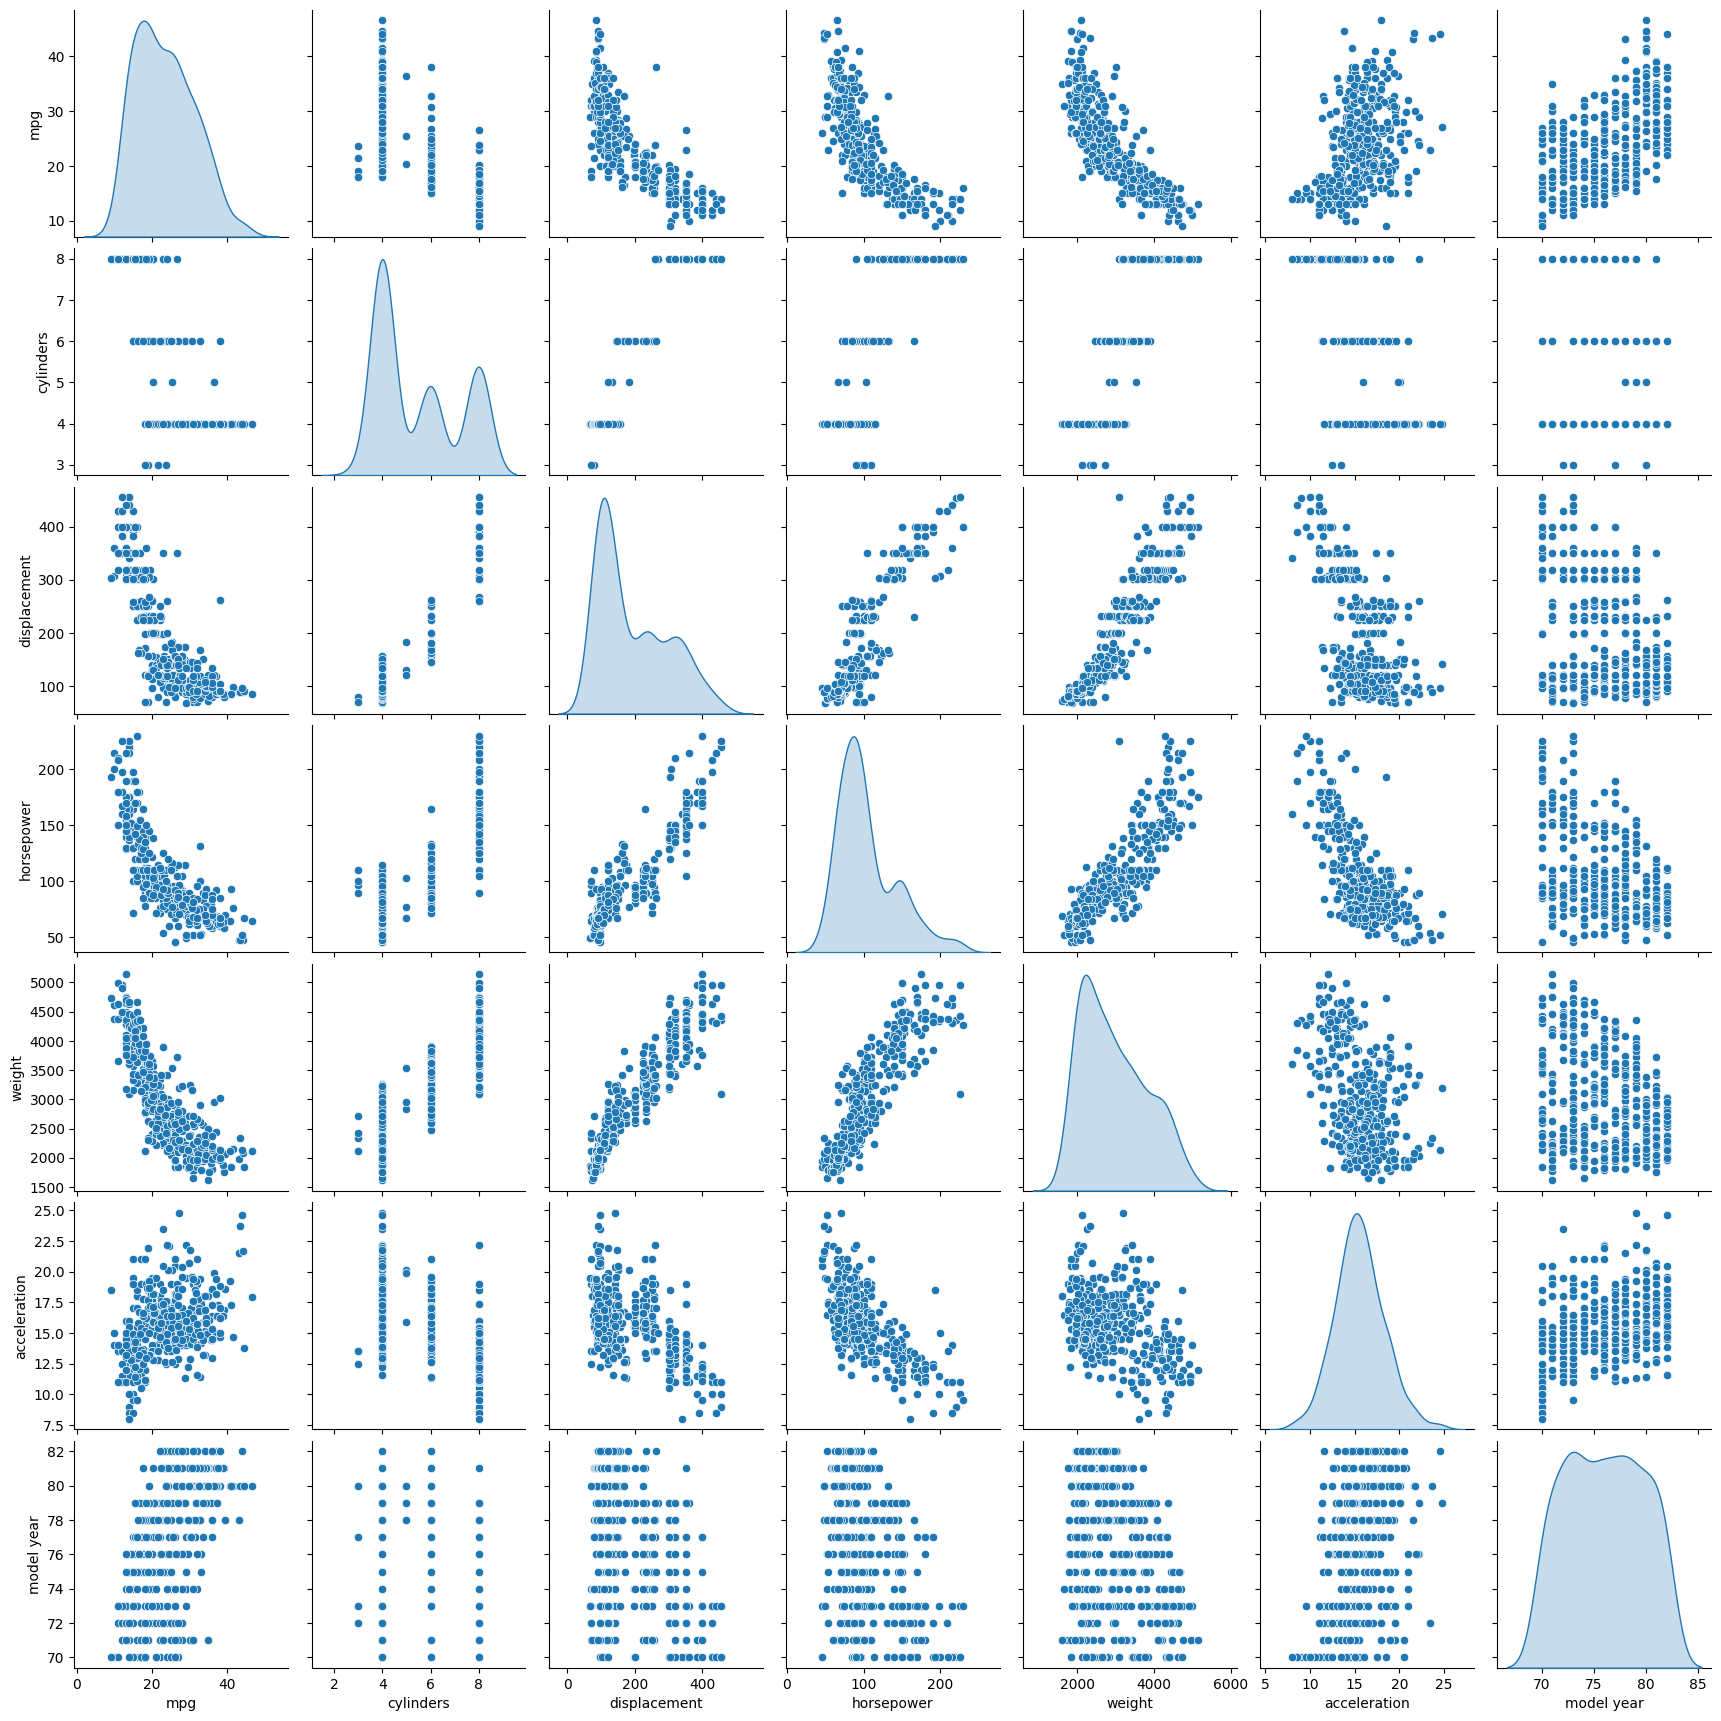

In [15]:
cData_attr = cData.iloc[:, 0:7]
sns.pairplot(cData_attr, diag_kind='kde')   # to plot density curve instead of histogram on the diag

Observation between 'mpg' and other attributes indicate the relationship is not really linear. However, the plots also indicate that linearity would still capture quite a bit of useful information/pattern. Several assumptions of classical linear regression seem to be violated, including the assumption of no Heteroscedasticity




**Observations**

1.   mpg vs other variables
*   mpg vs cylinders / displacement / horsepower / weight:
  *   Strong negative correlation: As these values increase, mpg tends to decrease.
  *   This makes sense—larger engines and heavier cars generally consume more fuel.
*   mpg vs acceleration:
  *   Slight positive correlation but not very strong.

*   mpg vs model year:
  *   Clear positive trend: More recent cars tend to be more fuel-efficient.

2.   Multicollinearity between independent variables
*   horsepower, displacement, and weight are strongly positively correlated with each other.
*   This suggests possible multicollinearity, which can affect linear regression model interpretability.

3.   Distribution of variables
*   mpg: Right-skewed distribution, some high-efficiency cars are outliers.
*   cylinders: Multi-modal due to its discrete nature.
*   horsepower and displacement: Skewed distributions (right-skewed).
*   model year: Uniform distribution (as expected from a range like 1970–1982).
*   acceleration: Fairly normal distribution.






**Correlation Heatmap**

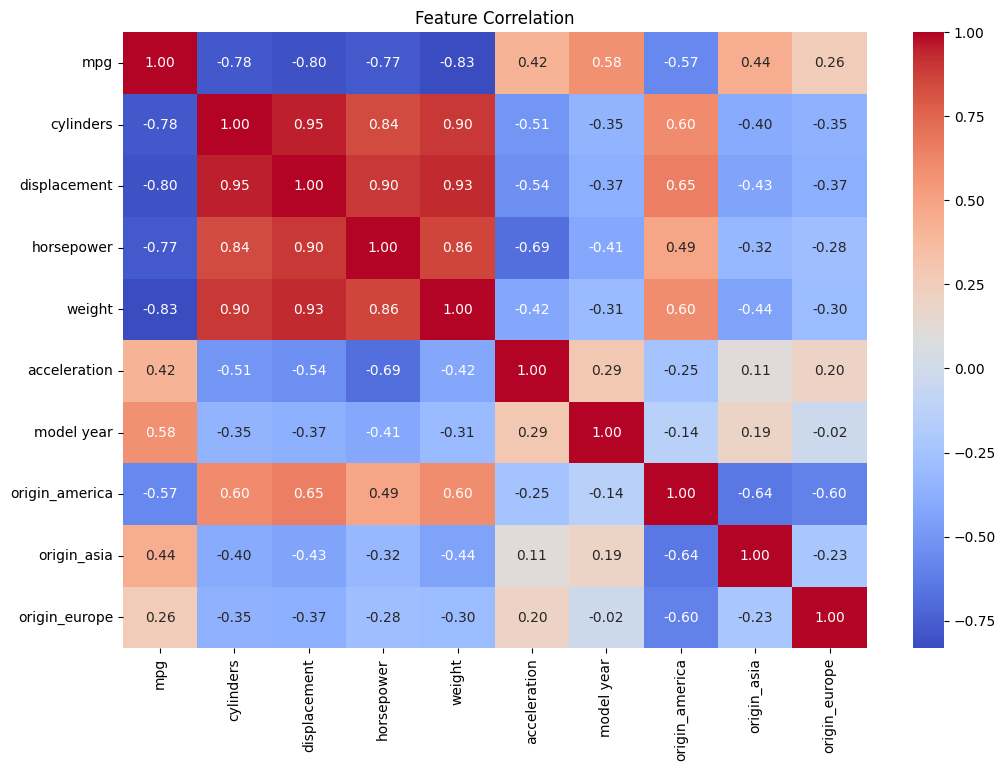

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(cData.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

**Observation**
*  High correlation (0.9+) between:
  *   displacement ↔ weight (0.93)
  *   displacement ↔ cylinders (0.95)
  *   horsepower ↔ displacement (0.90)
  *   cylinders ↔ weight (0.90)
*   These are classic signs of multicollinearity, which can make coefficient estimates unstable in linear regression.



**PCA to handle high coorelation**

Explained Variance Ratio: [0.55845482 0.14353551 0.13195466 0.07827507 0.06297889 0.01434679
 0.00684816 0.0036061  0.        ]


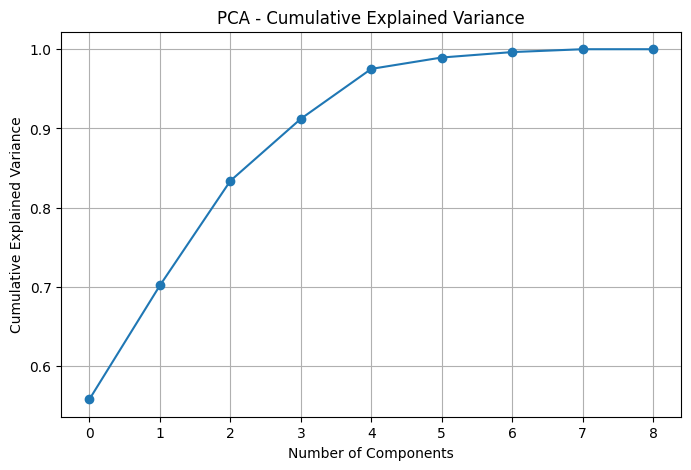

In [17]:
# Drop the target and categorical dummy variables (optional)
features = cData.drop(columns=['mpg'])  # 'mpg' is your target

# Optional: drop origin columns if you only want PCA on numeric predictors
# features = features.drop(columns=['origin_america', 'origin_asia', 'origin_europe'])

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply PCA
pca = PCA()
pca_features = pca.fit_transform(scaled_features)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()


**Building Model Using PCA Features**

In [18]:
# Choose top N components (e.g., top 5 that explain ~95% variance)
n_components = 5
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(scaled_features)

# Now split and train as usual
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X_pca, cData['mpg'], test_size=0.3, random_state=1)

model = LinearRegression()
model.fit(X_train, y_train)

print("Train R²:", model.score(X_train, y_train))
print("Test R² :", model.score(X_test, y_test))


Train R²: 0.7759348653663969
Test R² : 0.8225737066376959


**Assumption Check for Linear Regression**



1.   Linearity and Homoscedasticity



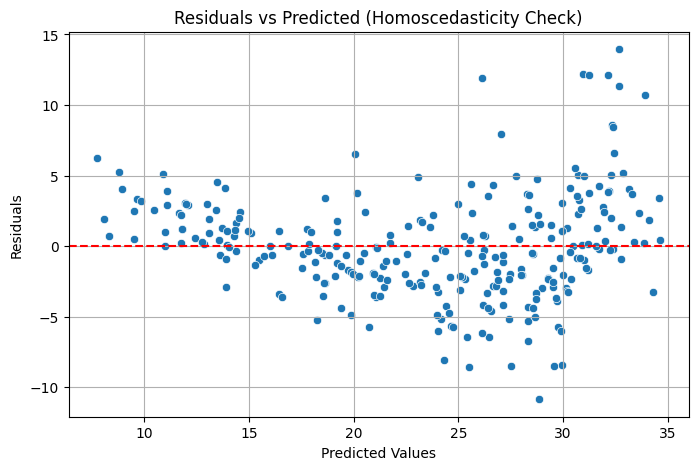

In [19]:
# Predictions on training set
y_pred_train = model.predict(X_train)
residuals = y_train - y_pred_train

# Residual vs Predicted plot
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_train, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Homoscedasticity Check)")
plt.grid(True)
plt.show()


**Observations**
*   Mostly satisfied: The residuals fluctuate around the horizontal line at 0, without a clear curved pattern.
*   This suggests that the linear relationship between predictors and the target (mpg) is reasonable.




2.   Normality of Residuals



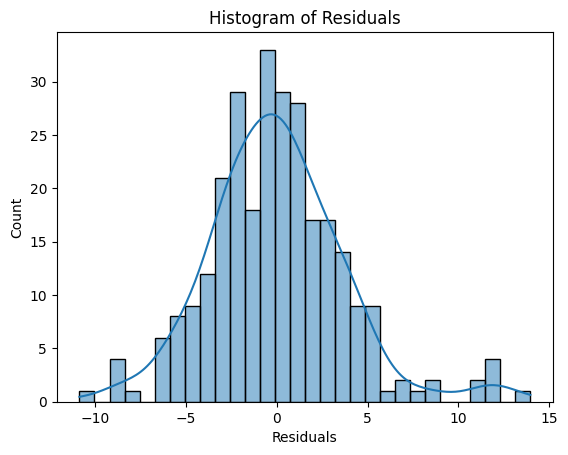

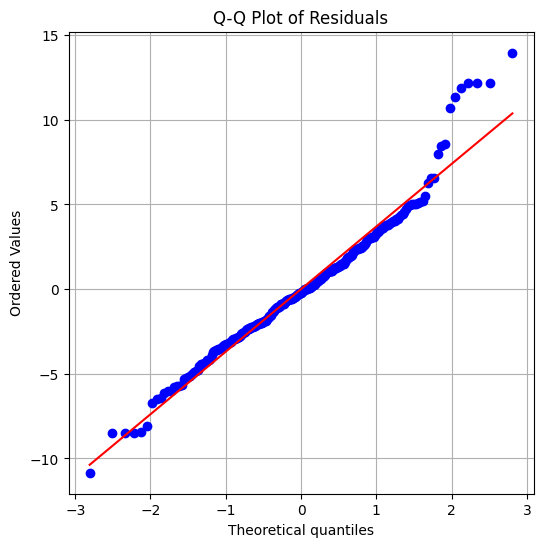

In [20]:
# Histogram + KDE
sns.histplot(residuals, kde=True, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.show()

# Q-Q Plot
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.grid(True)
plt.show()


**Observations**


*   Histogram is resembling a bell curve, and points in the Q-Q plot are close to the line.




3.   Independence of Errors
*   Since data isn’t time-series, this assumption generally holds.
4.   No Multicollinearity
*   Already handled using PCA since components are orthogonal (no correlation between them).





**Overfitting/Underfitting Check**

In [21]:
# R^2 scores
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print(f"Train R² Score: {train_r2:.4f}")
print(f"Test R² Score : {test_r2:.4f}")

# Interpretation
if abs(train_r2 - test_r2) < 0.05:
    print("✅ Model is well-generalized. No overfitting or underfitting.")
elif train_r2 > test_r2:
    print("⚠️ Model might be overfitting — too complex, memorizing training data.")
else:
    print("⚠️ Model might be underfitting — too simple to capture relationships.")


Train R² Score: 0.7759
Test R² Score : 0.8226
✅ Model is well-generalized. No overfitting or underfitting.


**Actual vs Predicted Plot**

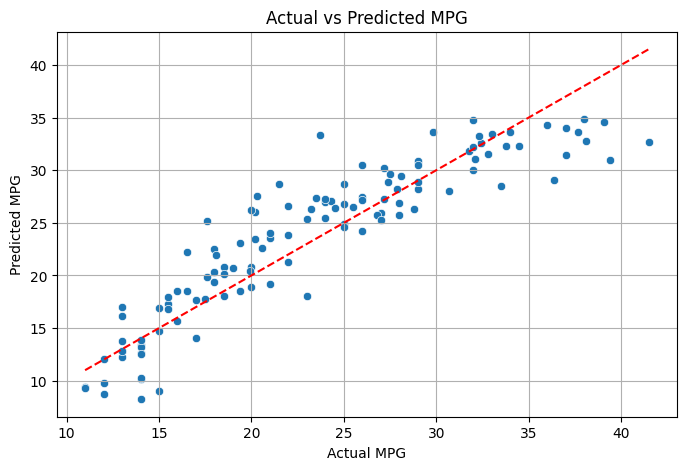

In [22]:
plt.figure(figsize=(8,5))
# Make predictions on the test set
y_pred_test = model.predict(X_test)
sns.scatterplot(x=y_test, y=y_pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # 45-degree line
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.grid(True)
plt.show()


## Split Data

In [23]:
# lets build our linear model
# independant variables
X = cData.drop(['mpg','origin_europe'], axis=1)
# the dependent variable
y = cData[['mpg']]

In [24]:
# Split X and y into training and test set in 70:30 ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

## Fit Linear Model

In [25]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

Here are the coefficients for each variable and the intercept

In [26]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for cylinders is -0.39480796616482383
The coefficient for displacement is 0.02894551076548718
The coefficient for horsepower is -0.021752207723546777
The coefficient for weight is -0.007352032065147351
The coefficient for acceleration is 0.061919366007618756
The coefficient for model year is 0.836933891764499
The coefficient for origin_america is -3.001283000918514
The coefficient for origin_asia is -0.6060179643247368


In [27]:
intercept = regression_model.intercept_[0]
print("The intercept for our model is {}".format(intercept))

The intercept for our model is -18.283451116372046


The score (R^2) for in-sample and out of sample

In [28]:
regression_model.score(X_train, y_train)

0.8141025501610559

In [29]:
#out of sample score (R^2)

regression_model.score(X_test, y_test)


0.8433135132808833

## Adding interaction terms


In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.fit_transform(X_test)

poly_clf = linear_model.LinearRegression()

poly_clf.fit(X_train2, y_train)

y_pred = poly_clf.predict(X_test2)

#print(y_pred)

#In sample (training) R^2 will always improve with the number of variables!
print(poly_clf.score(X_train2, y_train))

0.9026446935642735


In [31]:
#Out off sample (testing) R^2 is our measure of sucess and does improve
print(poly_clf.score(X_test2, y_test))

0.8668600517980215


In [32]:
# but this improves as the cost of 29 extra variables!
print(X_train.shape)
print(X_train2.shape)

(278, 8)
(278, 37)


Polynomial Features (with only interaction terms) have improved the Out of sample R^2. However at the cost of increaing the number of variables significantly.
